# Predicción de Notas Sensoriales de Café usando K-means (Modelo No Supervisado)

## Objetivo
Este notebook implementa un modelo de machine learning **no supervisado** usando **K-means** para predecir las características sensoriales (notas y sabores) de café de alta calidad basándose en parámetros de entrada como:
- País de origen
- Método de procesamiento
- Variedad del café
- Altitud
- Otras características físicas

**Aplicación práctica**: Para empresas procesadoras de café de alta calidad que necesitan predecir las notas y sabores resultantes según las condiciones de entrada del café.


In [1]:
"""
BLOQUE 1: IMPORTACIONES Y CONFIGURACIÓN INICIAL
================================================
Este bloque importa todas las librerías necesarias para el análisis.

Funcionalidad:
- pathlib.Path: Manejo de rutas de archivos
- dataclass: Para crear clases de datos estructuradas
- numpy, pandas: Manipulación de datos
- matplotlib, seaborn: Visualizaciones
- sklearn: Preprocesamiento y métricas
- imblearn: Para balanceo de datos (SMOTE)
"""
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Para balanceo de datos
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("⚠️  imblearn no está disponible. Instala con: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# Configuración de visualización
try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("seaborn")

sns.set_palette("husl")
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None

import warnings
warnings.filterwarnings('ignore')

# Rutas
BASE_DIR = Path(".")
MERGED_DATASET = BASE_DIR / "merged_data_cleaned.csv"

print("✅ Importaciones completadas")


✅ Importaciones completadas


In [2]:
"""
BLOQUE 2: FUNCIONES DE K-MEANS (NO SUPERVISADO)
=================================================
Implementación manual de K-means y funciones auxiliares.

Funcionalidad:
- ClusterEvaluation: Almacena resultados de evaluación de clustering
- kmeans_algorithm: Implementación manual de K-means
- silhouette_score_custom: Cálculo de silhouette score
- evaluate_kmeans: Evalúa diferentes valores de k
- select_best_evaluation: Selecciona el mejor k basado en silhouette
- project_pca: Proyección PCA para visualización
- cluster_report: Genera reporte de clusters
- run_kmeans_pipeline: Pipeline completo de K-means
"""
@dataclass
class ClusterEvaluation:
    """Almacena los resultados de una evaluación de clustering."""
    k: int
    inertia: float
    silhouette: float
    labels: np.ndarray
    centroids: np.ndarray


def kmeans_algorithm(
    matrix: np.ndarray,
    n_clusters: int,
    *,
    max_iter: int = 300,
    tol: float = 1e-4,
    n_init: int = 10,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Implementación manual de K-means.
    
    Returns:
        labels: Etiquetas de cluster asignadas
        centroids: Centroides de cada cluster
        inertia: Suma de distancias al cuadrado a los centroides
    """
    rng = np.random.default_rng(random_state)
    n_samples, n_features = matrix.shape
    
    best_inertia = np.inf
    best_labels = None
    best_centroids = None
    
    for _ in range(n_init):
        centroids = matrix[rng.choice(n_samples, n_clusters, replace=False)]
        
        for iteration in range(max_iter):
            # Asignar puntos al cluster más cercano
            distances = np.linalg.norm(matrix[:, None, :] - centroids[None, :, :], axis=2)
            labels = np.argmin(distances, axis=1)
            
            # Recalcular centroides
            new_centroids = np.zeros_like(centroids)
            for idx in range(n_clusters):
                members = matrix[labels == idx]
                if len(members) == 0:
                    new_centroids[idx] = matrix[rng.integers(0, n_samples)]
                else:
                    new_centroids[idx] = members.mean(axis=0)
            
            # Verificar convergencia
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            if shift <= tol:
                break
        
        # Calcular inercia
        final_distances = np.linalg.norm(matrix - centroids[labels], axis=1)
        inertia = float(np.sum(final_distances**2))
        
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()
    
    if best_labels is None or best_centroids is None:
        raise RuntimeError("K-means no convergió en todas las inicializaciones.")
    
    return best_labels, best_centroids, best_inertia


def silhouette_score_custom(matrix: np.ndarray, labels: np.ndarray) -> float:
    """
    Calcula el silhouette score para evaluar la calidad del clustering.
    
    Returns:
        Silhouette score promedio (entre -1 y 1, mayor es mejor)
    """
    unique_labels = np.unique(labels)
    if unique_labels.size < 2:
        return float("nan")
    
    distances = np.linalg.norm(matrix[:, None, :] - matrix[None, :, :], axis=2)
    n_samples = matrix.shape[0]
    silhouette_values = np.empty(n_samples, dtype=float)
    
    for idx in range(n_samples):
        own_label = labels[idx]
        own_mask = labels == own_label
        own_count = np.sum(own_mask)
        
        if own_count == 1:
            silhouette_values[idx] = 0.0
            continue
        
        # Distancia promedio dentro del mismo cluster
        a = distances[idx, own_mask].sum() / (own_count - 1)
        
        # Distancia promedio al cluster más cercano
        b = np.inf
        for other_label in unique_labels:
            if other_label == own_label:
                continue
            other_mask = labels == other_label
            if not np.any(other_mask):
                continue
            mean_distance = distances[idx, other_mask].mean()
            if mean_distance < b:
                b = mean_distance
        
        silhouette_values[idx] = (b - a) / max(a, b)
    
    return float(np.nanmean(silhouette_values))


def evaluate_kmeans(
    matrix: np.ndarray,
    k_values: Sequence[int],
    *,
    random_state: int = 42,
) -> List[ClusterEvaluation]:
    """
    Evalúa K-means para diferentes valores de k.
    
    Returns:
        Lista de evaluaciones para cada k
    """
    evaluations: List[ClusterEvaluation] = []
    for k in k_values:
        if k < 2 or k >= len(matrix):
            continue
        try:
            labels, centroids, inertia = kmeans_algorithm(matrix, k, random_state=random_state)
            score = silhouette_score_custom(matrix, labels)
            evaluations.append(ClusterEvaluation(k, inertia, score, labels, centroids))
        except Exception as e:
            print(f"Error con k={k}: {e}")
            continue
    return evaluations


def select_best_evaluation(evaluations: Sequence[ClusterEvaluation]) -> Optional[ClusterEvaluation]:
    """
    Selecciona la mejor evaluación basada en el silhouette score.
    """
    if not evaluations:
        return None
    best = None
    best_score = -np.inf
    for evaluation in evaluations:
        score = evaluation.silhouette
        score_value = -np.inf if np.isnan(score) else score
        if score_value > best_score:
            best_score = score_value
            best = evaluation
    return best if best is not None else evaluations[0]


def project_pca(matrix: np.ndarray, n_components: int = 2) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Proyecta los datos a componentes principales para visualización.
    """
    if matrix.size == 0:
        return np.empty((0, 0)), np.empty((0, matrix.shape[1])), np.empty(0)
    
    n_components = min(n_components, matrix.shape[0], matrix.shape[1])
    if n_components == 0:
        return np.empty((matrix.shape[0], 0)), np.empty((0, matrix.shape[1])), np.empty(0)
    
    u, singular_values, vh = np.linalg.svd(matrix, full_matrices=False)
    components = vh[:n_components]
    scores = matrix @ components.T
    explained_variance = (singular_values**2) / (matrix.shape[0] - 1)
    total_variance = explained_variance.sum()
    explained_ratio = explained_variance[:n_components] / total_variance if total_variance else np.zeros(n_components)
    
    if scores.shape[1] == 1:
        scores = np.concatenate([scores, np.zeros((scores.shape[0], 1))], axis=1)
        explained_ratio = np.concatenate([explained_ratio, np.array([0.0])])
    
    return scores, components, explained_ratio


def cluster_report(imputed: pd.DataFrame, labels: np.ndarray) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Genera un reporte de los clusters encontrados.
    """
    clustered = imputed.copy()
    clustered["cluster"] = labels
    counts = clustered["cluster"].value_counts().sort_index()
    profile = clustered.groupby("cluster").mean().sort_index()
    return profile, counts


def run_kmeans_pipeline(
    matrix: np.ndarray,
    feature_names: List[str],
    *,
    k_max: int = 8,
    random_state: int = 42,
) -> Optional[Dict[str, object]]:
    """
    Ejecuta el pipeline completo de K-means.
    
    Returns:
        Diccionario con resultados del clustering
    """
    if matrix.size == 0:
        return None
    
    max_k = min(k_max, len(matrix) - 1, 10)
    k_values = [k for k in range(2, max_k + 1)]
    
    print(f"Evaluando K-means para k = {k_values}...")
    evaluations = evaluate_kmeans(matrix, k_values, random_state=random_state)
    
    if not evaluations:
        return None
    
    best = select_best_evaluation(evaluations)
    if best is None:
        return None
    
    # Crear DataFrame para reporte
    df_features = pd.DataFrame(matrix, columns=feature_names)
    profile, counts = cluster_report(df_features, best.labels)
    
    # Proyección PCA
    projection, components, explained_ratio = project_pca(matrix, n_components=2)
    
    return {
        "evaluations": evaluations,
        "best": best,
        "cluster_profile": profile,
        "cluster_counts": counts,
        "projection": projection,
        "explained_ratio": explained_ratio,
        "feature_names": feature_names
    }

print("✅ Funciones de K-means definidas")


✅ Funciones de K-means definidas


In [3]:
"""
BLOQUE 3: CARGA Y EXPLORACIÓN INICIAL DEL DATASET
==================================================
Carga el dataset merged y realiza exploración inicial.
"""
print("="*60)
print("CARGA DEL DATASET")
print("="*60)

df = pd.read_csv(MERGED_DATASET, index_col=0, low_memory=False)
df.columns = df.columns.str.strip()

print(f"\nDataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nPrimeras 3 filas:")
display(df.head(3))

print(f"\nInformación del dataset:")
df.info()

# Verificar distribución de Species (para balanceo)
if 'Species' in df.columns:
    print(f"\nDistribución de Species:")
    species_dist = df['Species'].value_counts()
    display(species_dist)
    print(f"\nProporción:")
    display(species_dist / len(df) * 100)
    
    print(f"\n⚠️  DESBALANCE DETECTADO:")
    print(f"   • Arabica: {species_dist.get('Arabica', 0)} muestras ({species_dist.get('Arabica', 0)/len(df)*100:.1f}%)")
    print(f"   • Robusta: {species_dist.get('Robusta', 0)} muestras ({species_dist.get('Robusta', 0)/len(df)*100:.1f}%)")


CARGA DEL DATASET

Dataset cargado: 1,339 filas × 43 columnas

Primeras 3 filas:


,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.00,10.00,10.00,8.75,90.58,0.12,0,0.00,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,"1,950.00","2,200.00","2,075.00"
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.00,10.00,10.00,8.58,89.92,0.12,0,0.00,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,"1,950.00","2,200.00","2,075.00"
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.42,8.50,8.42,8.42,8.33,8.42,10.00,10.00,10.00,9.25,89.75,0.00,0,0.00,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,"1,600.00","1,800.00","1,700.00"



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1339 entries, 0 to 1338
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species                1339 non-null   object 
 1   Owner                  1332 non-null   object 
 2   Country.of.Origin      1338 non-null   object 
 3   Farm.Name              980 non-null    object 
 4   Lot.Number             276 non-null    object 
 5   Mill                   1021 non-null   object 
 6   ICO.Number             1180 non-null   object 
 7   Company                1130 non-null   object 
 8   Altitude               1113 non-null   object 
 9   Region                 1280 non-null   object 
 10  Producer               1107 non-null   object 
 11  Number.of.Bags         1339 non-null   int64  
 12  Bag.Weight             1339 non-null   object 
 13  In.Country.Partner     1339 non-null   object 
 14  Harvest.Year           1292 non-nul

Species
Arabica    1311
Robusta      28
Name: count, dtype: int64


Proporción:


Species
Arabica   97.91
Robusta    2.09
Name: count, dtype: float64


⚠️  DESBALANCE DETECTADO:
   • Arabica: 1311 muestras (97.9%)
   • Robusta: 28 muestras (2.1%)


In [4]:
"""
BLOQUE 4: PREPARACIÓN DE CARACTERÍSTICAS DE ENTRADA Y SALIDA
==============================================================
Prepara las características de entrada (parámetros) y salida (notas sensoriales).

Características de ENTRADA (parámetros que controla la empresa):
- Country.of.Origin: País de origen
- Processing.Method: Método de procesamiento (Washed, Natural, etc.)
- Variety: Variedad del café
- altitude_mean_meters: Altitud promedio
- Moisture: Humedad

Características de SALIDA (notas sensoriales a predecir):
- Aroma: Aroma del café
- Flavor: Sabor
- Aftertaste: Retrogusto
- Acidity: Acidez
- Body: Cuerpo
- Balance: Balance
- Total.Cup.Points: Puntos totales
"""
print("="*60)
print("PREPARACIÓN DE CARACTERÍSTICAS")
print("="*60)

# Características de ENTRADA (parámetros)
input_features_categorical = [
    'Country.of.Origin',
    'Processing.Method',
    'Variety'
]

input_features_numeric = [
    'altitude_mean_meters',
    'Moisture',
    'Category.One.Defects',
    'Category.Two.Defects'
]

# Características de SALIDA (notas sensoriales)
output_features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Total.Cup.Points'
]

# Seleccionar características disponibles
available_categorical = [f for f in input_features_categorical if f in df.columns]
available_numeric_input = [f for f in input_features_numeric if f in df.columns]
available_output = [f for f in output_features if f in df.columns]

print(f"\nCaracterísticas categóricas de entrada: {available_categorical}")
print(f"Características numéricas de entrada: {available_numeric_input}")
print(f"Características de salida (notas): {available_output}")

# Crear dataset con todas las características necesarias
all_features = available_categorical + available_numeric_input + available_output
df_features = df[all_features].copy()

# Eliminar filas donde falten TODAS las características de entrada o salida
df_features = df_features.dropna(subset=available_output, how='all')
df_features = df_features.dropna(subset=available_numeric_input, how='all')

print(f"\nDataset después de limpieza: {len(df_features):,} muestras")

# Imputar valores faltantes
for col in available_numeric_input + available_output:
    if col in df_features.columns:
        df_features[col] = df_features[col].fillna(df_features[col].mean())

# Para características categóricas, usar moda o 'Unknown'
for col in available_categorical:
    if col in df_features.columns:
        df_features[col] = df_features[col].fillna('Unknown')

print(f"\n✅ Dataset preparado: {len(df_features):,} muestras")
print(f"\nPrimeras filas:")
display(df_features.head())


PREPARACIÓN DE CARACTERÍSTICAS

Características categóricas de entrada: ['Country.of.Origin', 'Processing.Method', 'Variety']
Características numéricas de entrada: ['altitude_mean_meters', 'Moisture', 'Category.One.Defects', 'Category.Two.Defects']
Características de salida (notas): ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total.Cup.Points']

Dataset después de limpieza: 1,339 muestras

✅ Dataset preparado: 1,339 muestras

Primeras filas:


,Country.of.Origin,Processing.Method,Variety,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Total.Cup.Points
0,Ethiopia,Washed / Wet,Unknown,"2,075.00",0.12,0,0,8.67,8.83,8.67,8.75,8.50,8.42,90.58
1,Ethiopia,Washed / Wet,Other,"2,075.00",0.12,0,1,8.75,8.67,8.50,8.58,8.42,8.42,89.92
2,Guatemala,Unknown,Bourbon,"1,700.00",0.00,0,0,8.42,8.50,8.42,8.42,8.33,8.42,89.75
3,Ethiopia,Natural / Dry,Unknown,"2,000.00",0.11,0,2,8.17,8.58,8.42,8.42,8.50,8.25,89.00
4,Ethiopia,Washed / Wet,Other,"2,075.00",0.12,0,2,8.25,8.50,8.25,8.50,8.42,8.33,88.83


In [5]:
"""
BLOQUE 5: BALANCEO DEL DATASET
===============================
Balancea el dataset para tener una distribución más equilibrada.

Estrategia: Usaremos SMOTE (Synthetic Minority Oversampling Technique) para
generar muestras sintéticas de la clase minoritaria (Robusta) basándose en
las características numéricas disponibles.

IMPORTANTE: El balanceo se aplica a las características numéricas. Para las
categóricas, se usarán los valores más comunes del cluster correspondiente.
"""
print("="*60)
print("BALANCEO DEL DATASET")
print("="*60)

# Agregar Species a df_features si está disponible en df original
if 'Species' in df.columns and 'Species' not in df_features.columns:
    # Hacer merge con Species desde df original
    df_features = df_features.merge(
        df[['Species']], 
        left_index=True, 
        right_index=True, 
        how='left'
    )

# Verificar si tenemos Species para balancear
if 'Species' in df_features.columns and IMBLEARN_AVAILABLE:
    # Preparar datos para balanceo usando características numéricas
    balance_features = available_numeric_input + available_output
    
    # Crear dataset para balanceo
    df_balance = df_features[balance_features + ['Species']].copy()
    
    # Eliminar filas con Species faltante
    df_balance = df_balance.dropna(subset=['Species'])
    
    # Imputar valores faltantes
    for col in balance_features:
        if col in df_balance.columns:
            df_balance[col] = df_balance[col].fillna(df_balance[col].mean())
    
    # Separar X e y
    X_balance = df_balance[balance_features].values
    y_balance = df_balance['Species'].values
    
    # Codificar Species
    le_species = LabelEncoder()
    y_balance_encoded = le_species.fit_transform(y_balance)
    
    print(f"\nAntes del balanceo:")
    unique, counts = np.unique(y_balance_encoded, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"   • {le_species.inverse_transform([u])[0]}: {c} muestras")
    
    # Aplicar SMOTE
    try:
        print(f"\nAplicando SMOTE para balancear...")
        k_neighbors = min(5, min(counts) - 1) if min(counts) > 1 else 1
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_balance, y_balance_encoded)
        
        print(f"\nDespués del balanceo:")
        unique, counts = np.unique(y_balanced, return_counts=True)
        for u, c in zip(unique, counts):
            print(f"   • {le_species.inverse_transform([u])[0]}: {c} muestras")
        
        # Crear DataFrame balanceado con características numéricas
        df_balanced_numeric = pd.DataFrame(X_balanced, columns=balance_features)
        df_balanced_numeric['Species'] = le_species.inverse_transform(y_balanced)
        
        # Para características categóricas, asignar valores basados en Species
        # Usar los valores más comunes de cada categoría para cada Species
        df_balanced_categorical = pd.DataFrame()
        for col in available_categorical:
            if col in df_features.columns:
                # Para cada Species, usar el valor más común de esa categoría
                species_mode = {}
                for species in df_balanced_numeric['Species'].unique():
                    species_data = df_features[df_features['Species'] == species]
                    if len(species_data) > 0 and col in species_data.columns:
                        mode_val = species_data[col].mode()[0] if len(species_data[col].mode()) > 0 else 'Unknown'
                        species_mode[species] = mode_val
                    else:
                        species_mode[species] = 'Unknown'
                
                # Asignar valores según Species
                df_balanced_categorical[col] = df_balanced_numeric['Species'].map(species_mode)
        
        # Combinar numéricas y categóricas
        if len(df_balanced_categorical) > 0:
            df_final = pd.concat([df_balanced_categorical.reset_index(drop=True), 
                                 df_balanced_numeric.reset_index(drop=True)], axis=1)
        else:
            df_final = df_balanced_numeric.copy()
        
        # Asegurar que tenemos todas las columnas necesarias
        for col in available_output:
            if col not in df_final.columns:
                df_final[col] = df_balanced_numeric[col]
        
        print(f"\n✅ Dataset balanceado creado: {len(df_final):,} muestras")
        print(f"   • Características numéricas: balanceadas con SMOTE")
        print(f"   • Características categóricas: asignadas según Species")
        
    except Exception as e:
        print(f"\n⚠️  Error al aplicar SMOTE: {e}")
        print(f"   Usando dataset original sin balancear")
        df_final = df_features.copy()
else:
    print(f"\n⚠️  No se puede balancear: imblearn no disponible o Species no encontrado")
    print(f"   Usando dataset original sin balancear")
    df_final = df_features.copy()

print(f"\n📊 Dataset final para análisis: {len(df_final):,} muestras")
print(f"\nDistribución final de Species (si disponible):")
if 'Species' in df_final.columns:
    display(df_final['Species'].value_counts())


BALANCEO DEL DATASET

Antes del balanceo:
   • Arabica: 1311 muestras
   • Robusta: 28 muestras

Aplicando SMOTE para balancear...

Después del balanceo:
   • Arabica: 1311 muestras
   • Robusta: 1311 muestras

✅ Dataset balanceado creado: 2,622 muestras
   • Características numéricas: balanceadas con SMOTE
   • Características categóricas: asignadas según Species

📊 Dataset final para análisis: 2,622 muestras

Distribución final de Species (si disponible):


Species
Arabica    1311
Robusta    1311
Name: count, dtype: int64

In [6]:
"""
BLOQUE 6: CODIFICACIÓN DE CARACTERÍSTICAS
==========================================
Codifica las características categóricas y prepara los datos para K-means.
"""
print("="*60)
print("CODIFICACIÓN DE CARACTERÍSTICAS")
print("="*60)

# Codificar características categóricas usando LabelEncoder
X_categorical = df_final[available_categorical].copy()
X_numeric = df_final[available_numeric_input].copy()
y_output = df_final[available_output].copy()

# Label Encoding para categóricas
X_encoded_list = []
feature_names_encoded = []
encoders = {}

for col in available_categorical:
    if col in X_categorical.columns:
        le = LabelEncoder()
        encoded = le.fit_transform(X_categorical[col].astype(str))
        X_encoded_list.append(encoded.reshape(-1, 1))
        feature_names_encoded.append(col)
        encoders[col] = le

# Combinar características codificadas
if X_encoded_list:
    X_encoded = np.hstack(X_encoded_list)
else:
    X_encoded = np.array([]).reshape(len(df_final), 0)

# Combinar con características numéricas
X_numeric_array = X_numeric.values

if X_encoded.size > 0:
    X_input = np.hstack([X_encoded, X_numeric_array])
    input_feature_names = feature_names_encoded + available_numeric_input
else:
    X_input = X_numeric_array
    input_feature_names = available_numeric_input.copy()

# Características de salida
y_output_array = y_output.values

print(f"\nDimensiones:")
print(f"   • X_input (entrada): {X_input.shape}")
print(f"   • y_output (salida): {y_output_array.shape}")
print(f"   • Características de entrada: {input_feature_names}")
print(f"   • Características de salida: {available_output}")

# Estandarizar características de entrada
scaler_input = StandardScaler()
X_input_scaled = scaler_input.fit_transform(X_input)

# Estandarizar características de salida (para clustering conjunto)
scaler_output = StandardScaler()
y_output_scaled = scaler_output.fit_transform(y_output_array)

# Combinar entrada y salida para clustering (K-means agrupa por similitud total)
# Esto permite encontrar grupos de cafés similares en parámetros Y notas
X_combined = np.hstack([X_input_scaled, y_output_scaled])
combined_feature_names = input_feature_names + [f"output_{f}" for f in available_output]

print(f"\n✅ Datos preparados para K-means:")
print(f"   • X_combined: {X_combined.shape}")
print(f"   • Total características: {len(combined_feature_names)}")


CODIFICACIÓN DE CARACTERÍSTICAS

Dimensiones:
   • X_input (entrada): (2622, 7)
   • y_output (salida): (2622, 7)
   • Características de entrada: ['Country.of.Origin', 'Processing.Method', 'Variety', 'altitude_mean_meters', 'Moisture', 'Category.One.Defects', 'Category.Two.Defects']
   • Características de salida: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total.Cup.Points']

✅ Datos preparados para K-means:
   • X_combined: (2622, 14)
   • Total características: 14


EJECUCIÓN DE K-MEANS (MODELO NO SUPERVISADO)
Evaluando K-means para k = [2, 3, 4, 5, 6, 7, 8]...

EVALUACIÓN DE DIFERENTES VALORES DE K


,k,Inercia,Silhouette Score
0,2,"27,970.12",0.34
1,3,"22,744.93",0.35
2,4,"20,107.34",0.34
3,5,"16,995.55",0.34
4,6,"17,126.70",0.29
5,7,"14,805.68",0.32
6,8,"13,100.73",0.27



✅ Mejor configuración: k=3
   • Silhouette Score: 0.352
   • Inercia: 22744.93

DISTRIBUCIÓN DE OBSERVACIONES POR CLUSTER


,Observaciones
cluster,
0,1188
1,1120
2,314



PERFIL PROMEDIO DE CARACTERÍSTICAS POR CLUSTER


,Country.of.Origin,Processing.Method,Variety,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,output_Aroma,output_Flavor,output_Aftertaste,output_Acidity,output_Body,output_Balance,output_Total.Cup.Points
cluster,,,,,,,,,,,,,,
0,-1.00,-1.00,1.00,-0.04,-0.26,-0.18,-0.26,0.34,0.33,0.39,0.33,0.15,0.26,-0.05
1,1.00,1.00,-1.00,0.05,0.15,-0.19,0.05,0.02,0.13,0.06,0.04,0.13,0.16,0.49
2,0.22,0.22,-0.22,-0.03,0.44,1.37,0.82,-1.34,-1.71,-1.69,-1.40,-1.02,-1.55,-1.55



VISUALIZACIÓN DE CLUSTERS CON PCA


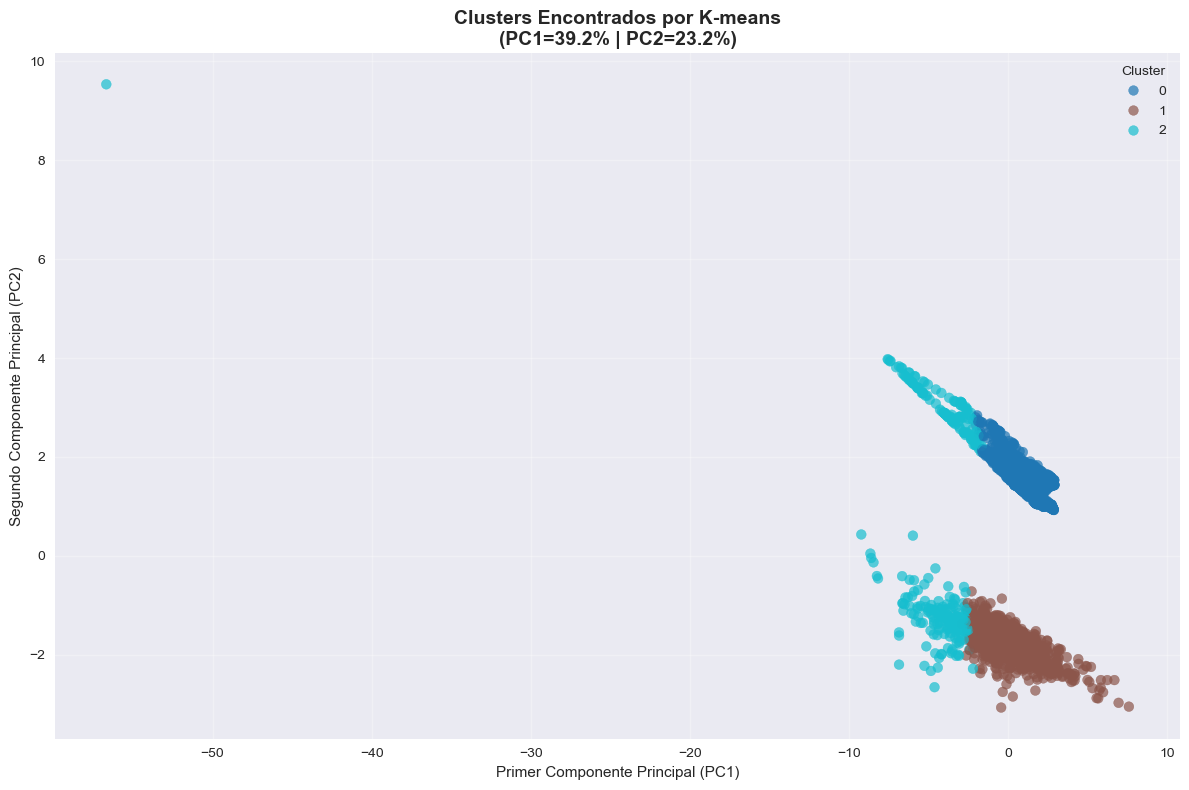


✅ Análisis de clustering completado


In [7]:
"""
BLOQUE 7: EJECUCIÓN DE K-MEANS
===============================
Ejecuta K-means para encontrar grupos naturales de cafés.
"""
print("="*60)
print("EJECUCIÓN DE K-MEANS (MODELO NO SUPERVISADO)")
print("="*60)

# Ejecutar pipeline de K-means
kmeans_results = run_kmeans_pipeline(
    X_combined,
    combined_feature_names,
    k_max=8,
    random_state=42
)

if kmeans_results:
    # Mostrar evaluaciones
    print("\n" + "="*60)
    print("EVALUACIÓN DE DIFERENTES VALORES DE K")
    print("="*60)
    
    eval_df = pd.DataFrame({
        "k": [e.k for e in kmeans_results["evaluations"]],
        "Inercia": [e.inertia for e in kmeans_results["evaluations"]],
        "Silhouette Score": [e.silhouette for e in kmeans_results["evaluations"]],
    })
    display(eval_df)
    
    best_kmeans = kmeans_results["best"]
    print(f"\n✅ Mejor configuración: k={best_kmeans.k}")
    print(f"   • Silhouette Score: {best_kmeans.silhouette:.3f}")
    print(f"   • Inercia: {best_kmeans.inertia:.2f}")
    
    # Conteo de clusters
    print(f"\n" + "="*60)
    print("DISTRIBUCIÓN DE OBSERVACIONES POR CLUSTER")
    print("="*60)
    display(kmeans_results["cluster_counts"].to_frame("Observaciones"))
    
    # Perfil de clusters (promedio de características)
    print(f"\n" + "="*60)
    print("PERFIL PROMEDIO DE CARACTERÍSTICAS POR CLUSTER")
    print("="*60)
    display(kmeans_results["cluster_profile"].round(2))
    
    # Visualización con PCA
    print(f"\n" + "="*60)
    print("VISUALIZACIÓN DE CLUSTERS CON PCA")
    print("="*60)
    
    projection = kmeans_results["projection"]
    explained = kmeans_results["explained_ratio"] * 100
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    coords = pd.DataFrame(projection, columns=["PC1", "PC2"])
    coords["cluster"] = best_kmeans.labels
    
    scatter = ax.scatter(coords["PC1"], coords["PC2"], 
                        c=coords["cluster"], cmap="tab10", alpha=0.7, s=50)
    ax.set_title(f'Clusters Encontrados por K-means\n(PC1={explained[0]:.1f}% | PC2={explained[1]:.1f}%)',
                fontsize=14, fontweight='bold')
    ax.set_xlabel("Primer Componente Principal (PC1)")
    ax.set_ylabel("Segundo Componente Principal (PC2)")
    ax.legend(*scatter.legend_elements(), title="Cluster")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Análisis de clustering completado")
else:
    print("\n❌ No se pudo ejecutar el análisis de clustering")


ANÁLISIS DE PERFILES DE CLUSTERS

📊 CARACTERÍSTICAS DE ENTRADA POR CLUSTER:

🔹 CLUSTER 0 (1188 muestras):
   • Country.of.Origin: India
   • Processing.Method: Unknown
   • Variety: Unknown
   • altitude_mean_meters: 1401.29
   • Moisture: 0.06
   • Category.One.Defects: 0.36
   • Category.Two.Defects: 1.60

🔹 CLUSTER 1 (1120 muestras):
   • Country.of.Origin: Mexico
   • Processing.Method: Washed / Wet
   • Variety: Caturra
   • altitude_mean_meters: 1860.75
   • Moisture: 0.09
   • Category.One.Defects: 0.32
   • Category.Two.Defects: 2.88

🔹 CLUSTER 2 (314 muestras):
   • Country.of.Origin: Mexico
   • Processing.Method: Washed / Wet
   • Variety: Caturra
   • altitude_mean_meters: 1460.68
   • Moisture: 0.10
   • Category.One.Defects: 10.83
   • Category.Two.Defects: 6.05


📊 NOTAS SENSORIALES PROMEDIO POR CLUSTER:


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Total.Cup.Points
Cluster,,,,,,,
0,7.74,7.68,7.61,7.70,7.59,7.65,81.34
1,7.64,7.61,7.50,7.61,7.58,7.61,82.92
2,7.20,6.99,6.86,7.15,7.03,6.99,76.95


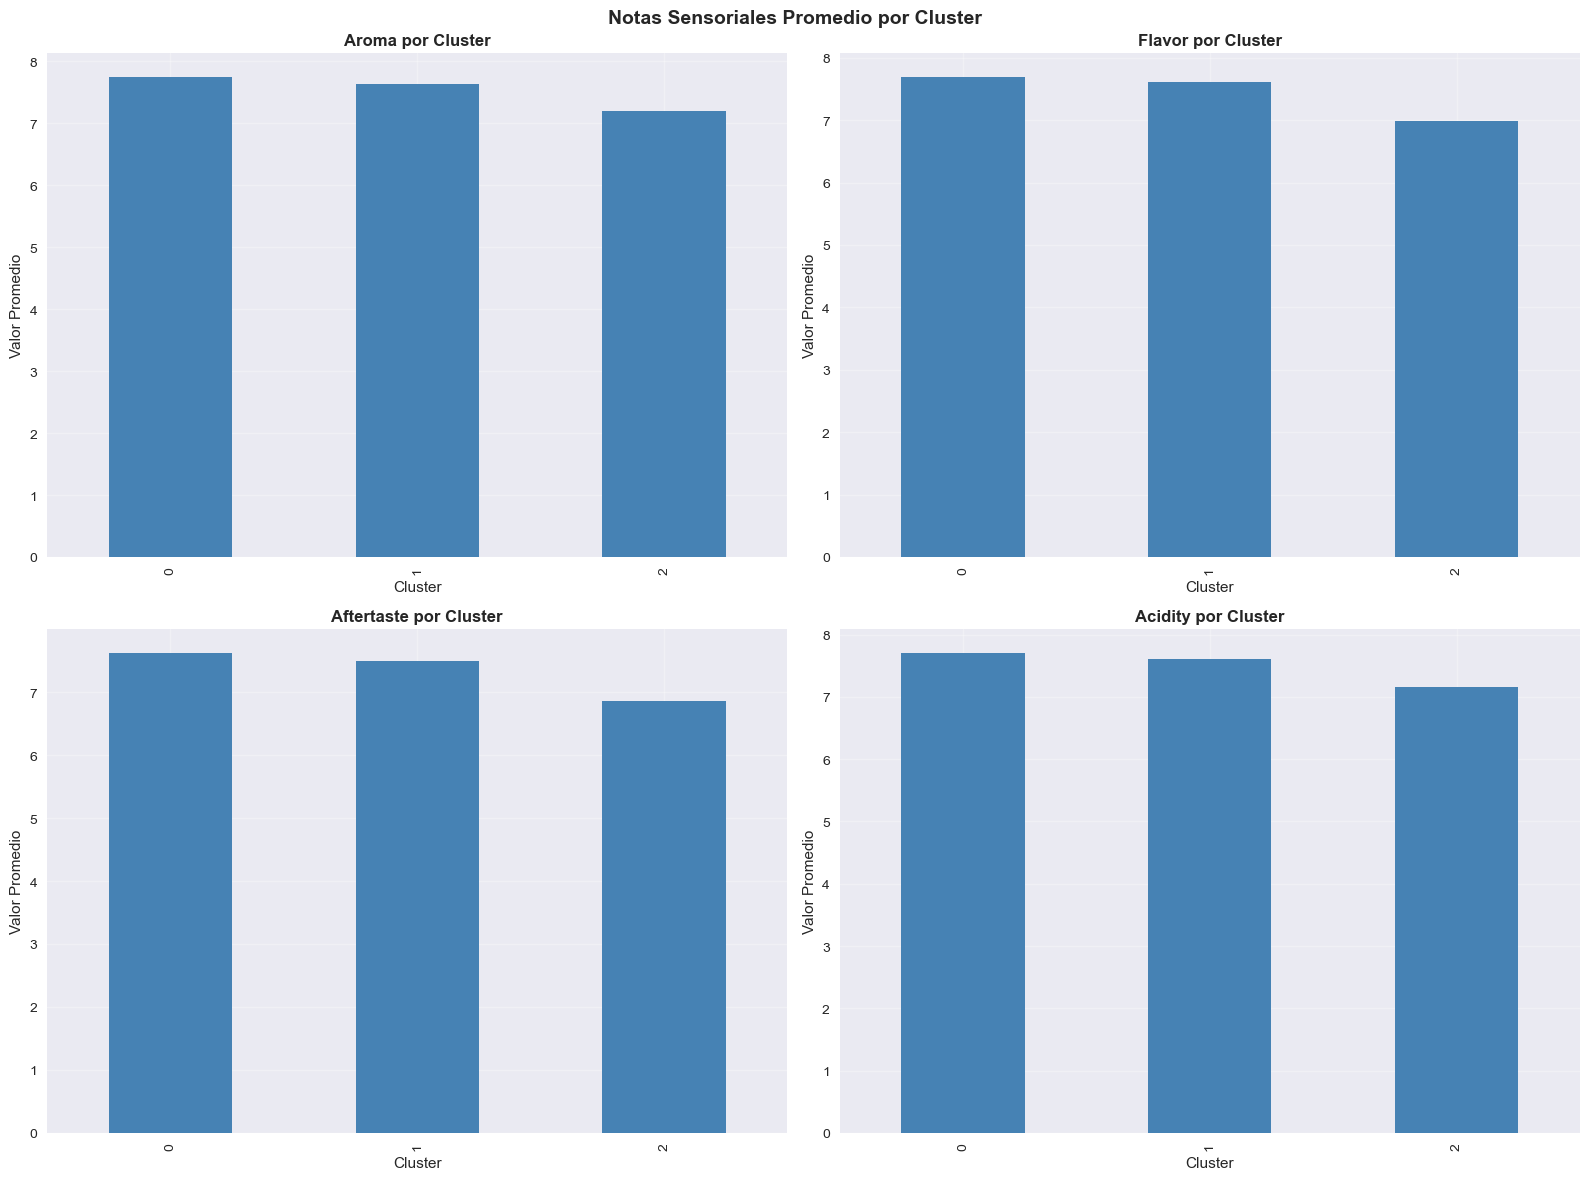


✅ Análisis de perfiles completado


In [10]:
"""
BLOQUE 8: ANÁLISIS DE PERFILES DE CLUSTERS
===========================================
Analiza los perfiles de cada cluster para entender qué tipos de café agrupa.
"""
print("="*60)
print("ANÁLISIS DE PERFILES DE CLUSTERS")
print("="*60)

if kmeans_results:
    best_kmeans = kmeans_results["best"]
    
    # Crear DataFrame con clusters y características originales
    df_clustered = df_final.copy()
    df_clustered['Cluster'] = best_kmeans.labels
    
    # Analizar características de entrada por cluster
    print("\n📊 CARACTERÍSTICAS DE ENTRADA POR CLUSTER:")
    print("="*60)
    
    for cluster_id in sorted(df_clustered['Cluster'].unique()):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
        print(f"\n🔹 CLUSTER {cluster_id} ({len(cluster_data)} muestras):")
        
        # Características categóricas
        for col in available_categorical:
            if col in cluster_data.columns:
                mode_value = cluster_data[col].mode()[0] if len(cluster_data[col].mode()) > 0 else 'N/A'
                print(f"   • {col}: {mode_value}")
        
        # Características numéricas
        for col in available_numeric_input:
            if col in cluster_data.columns:
                mean_val = cluster_data[col].mean()
                print(f"   • {col}: {mean_val:.2f}")
    
    # Analizar características de salida (notas) por cluster
    print("\n\n📊 NOTAS SENSORIALES PROMEDIO POR CLUSTER:")
    print("="*60)
    
    notes_by_cluster = df_clustered.groupby('Cluster')[available_output].mean()
    display(notes_by_cluster.round(2))
    
    # Visualización de notas por cluster
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, note in enumerate(available_output[:4]):
        if idx < len(axes):
            notes_by_cluster[note].plot(kind='bar', ax=axes[idx], color='steelblue')
            axes[idx].set_title(f'{note} por Cluster', fontweight='bold')
            axes[idx].set_xlabel('Cluster')
            axes[idx].set_ylabel('Valor Promedio')
            axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Notas Sensoriales Promedio por Cluster', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Análisis de perfiles completado")


In [11]:
"""
BLOQUE 9: FUNCIÓN DE PREDICCIÓN BASADA EN K-MEANS
===================================================
Crea una función que predice las notas sensoriales basándose en:
1. Asignar el nuevo café al cluster más cercano
2. Usar el perfil promedio de notas de ese cluster como predicción

Esta es la aplicación práctica para la empresa procesadora de café.
"""
print("="*60)
print("FUNCIÓN DE PREDICCIÓN DE NOTAS SENSORIALES")
print("="*60)

def predecir_notas_sensoriales(
    country_of_origin: str = None,
    processing_method: str = None,
    variety: str = None,
    altitude_mean: float = None,
    moisture: float = None,
    category_one_defects: int = 0,
    category_two_defects: int = 0
) -> Dict:
    """
    Predice las notas sensoriales de un café basándose en sus parámetros de entrada.
    
    Parameters:
        country_of_origin: País de origen del café
        processing_method: Método de procesamiento (Washed, Natural, etc.)
        variety: Variedad del café
        altitude_mean: Altitud promedio en metros
        moisture: Humedad
        category_one_defects: Defectos categoría 1
        category_two_defects: Defectos categoría 2
    
    Returns:
        Diccionario con:
            - cluster_asignado: Cluster al que pertenece el café
            - notas_predichas: Diccionario con notas sensoriales predichas
            - confianza: Distancia al centroide (menor = mayor confianza)
    """
    if not kmeans_results:
        raise ValueError("K-means no está disponible. Ejecuta primero el análisis de clustering.")
    
    best_kmeans = kmeans_results["best"]
    
    # Preparar características de entrada
    input_values = {}
    
    # Codificar características categóricas
    for col in available_categorical:
        if col == 'Country.of.Origin':
            value = country_of_origin if country_of_origin else 'Unknown'
        elif col == 'Processing.Method':
            value = processing_method if processing_method else 'Unknown'
        elif col == 'Variety':
            value = variety if variety else 'Unknown'
        else:
            value = 'Unknown'
        
        if col in encoders:
            try:
                # Intentar codificar el valor
                if value in encoders[col].classes_:
                    encoded = encoders[col].transform([value])[0]
                else:
                    # Si el valor no está en el encoder, usar el más común
                    encoded = encoders[col].transform([encoders[col].classes_[0]])[0]
            except:
                encoded = 0
            input_values[col] = encoded
    
    # Valores numéricos
    if 'altitude_mean_meters' in available_numeric_input:
        input_values['altitude_mean_meters'] = altitude_mean if altitude_mean is not None else df_final['altitude_mean_meters'].mean()
    if 'Moisture' in available_numeric_input:
        input_values['Moisture'] = moisture if moisture is not None else df_final['Moisture'].mean()
    if 'Category.One.Defects' in available_numeric_input:
        input_values['Category.One.Defects'] = category_one_defects
    if 'Category.Two.Defects' in available_numeric_input:
        input_values['Category.Two.Defects'] = category_two_defects
    
    # Construir vector de entrada
    input_vector = []
    for name in input_feature_names:
        if name in input_values:
            input_vector.append(input_values[name])
        else:
            # Usar valor promedio si no está disponible
            if name in df_final.columns:
                input_vector.append(df_final[name].mean())
            else:
                input_vector.append(0.0)
    
    input_vector = np.array(input_vector).reshape(1, -1)
    
    # Estandarizar
    input_scaled = scaler_input.transform(input_vector)
    
    # Calcular distancia a cada centroide (solo parte de entrada)
    centroids = best_kmeans.centroids
    n_input_features = len(input_feature_names)
    
    # Distancia basada solo en características de entrada
    input_centroids = centroids[:, :n_input_features]
    distances = np.linalg.norm(input_centroids - input_scaled, axis=1)
    cluster_asignado = np.argmin(distances)
    distancia_centroide = distances[cluster_asignado]
    
    # Obtener perfil de notas del cluster asignado
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_asignado]
    
    notas_predichas = {}
    for note in available_output:
        if note in cluster_data.columns:
            notas_predichas[note] = float(cluster_data[note].mean())
    
    # Calcular confianza (inversa de la distancia)
    confianza = max(0, 100 - (distancia_centroide * 10))
    
    return {
        'cluster_asignado': int(cluster_asignado),
        'notas_predichas': notas_predichas,
        'confianza': round(confianza, 1),
        'distancia_centroide': round(float(distancia_centroide), 3),
        'metodo': 'K-means (No supervisado)'
    }

print("\n✅ Función de predicción definida")
print("\nEjemplos de uso:")
print("  resultado = predecir_notas_sensoriales(")
print("      country_of_origin='Ethiopia',")
print("      processing_method='Washed / Wet',")
print("      altitude_mean=2000.0,")
print("      moisture=0.12")
print("  )")


FUNCIÓN DE PREDICCIÓN DE NOTAS SENSORIALES

✅ Función de predicción definida

Ejemplos de uso:
  resultado = predecir_notas_sensoriales(
      country_of_origin='Ethiopia',
      processing_method='Washed / Wet',
      altitude_mean=2000.0,
      moisture=0.12
  )


In [12]:
"""
BLOQUE 10: EJEMPLOS DE PREDICCIÓN
==================================
Ejemplos prácticos de uso de la función de predicción.
"""
print("="*60)
print("EJEMPLOS DE PREDICCIÓN DE NOTAS SENSORIALES")
print("="*60)

# Ejemplo 1: Café de Etiopía, procesado lavado, alta altitud
print("\n" + "-"*60)
print("Ejemplo 1 - Café Etiopía (Alta Calidad):")
print("-"*60)
resultado1 = predecir_notas_sensoriales(
    country_of_origin='Ethiopia',
    processing_method='Washed / Wet',
    variety='Other',
    altitude_mean=2000.0,
    moisture=0.12,
    category_one_defects=0,
    category_two_defects=0
)

print(f"\n🔍 Resultado:")
print(f"   • Cluster asignado: {resultado1['cluster_asignado']}")
print(f"   • Confianza: {resultado1['confianza']:.1f}%")
print(f"   • Distancia al centroide: {resultado1['distancia_centroide']:.3f}")
print(f"\n📊 Notas Sensoriales Predichas:")
for nota, valor in resultado1['notas_predichas'].items():
    print(f"   • {nota}: {valor:.2f}")

# Ejemplo 2: Café de Brasil, procesado natural, media altitud
print("\n" + "-"*60)
print("Ejemplo 2 - Café Brasil (Procesado Natural):")
print("-"*60)
resultado2 = predecir_notas_sensoriales(
    country_of_origin='Brazil',
    processing_method='Natural / Dry',
    altitude_mean=1200.0,
    moisture=0.11
)

print(f"\n🔍 Resultado:")
print(f"   • Cluster asignado: {resultado2['cluster_asignado']}")
print(f"   • Confianza: {resultado2['confianza']:.1f}%")
print(f"   • Distancia al centroide: {resultado2['distancia_centroide']:.3f}")
print(f"\n📊 Notas Sensoriales Predichas:")
for nota, valor in resultado2['notas_predichas'].items():
    print(f"   • {nota}: {valor:.2f}")

# Ejemplo 3: Café de Guatemala, procesado lavado, muy alta altitud
print("\n" + "-"*60)
print("Ejemplo 3 - Café Guatemala (Muy Alta Altitud):")
print("-"*60)
resultado3 = predecir_notas_sensoriales(
    country_of_origin='Guatemala',
    processing_method='Washed / Wet',
    altitude_mean=1800.0,
    moisture=0.11
)

print(f"\n🔍 Resultado:")
print(f"   • Cluster asignado: {resultado3['cluster_asignado']}")
print(f"   • Confianza: {resultado3['confianza']:.1f}%")
print(f"   • Distancia al centroide: {resultado3['distancia_centroide']:.3f}")
print(f"\n📊 Notas Sensoriales Predichas:")
for nota, valor in resultado3['notas_predichas'].items():
    print(f"   • {nota}: {valor:.2f}")

print("\n" + "="*60)
print("RESUMEN")
print("="*60)
print("\n✅ El modelo K-means (no supervisado) puede predecir las notas sensoriales")
print("   basándose en los parámetros de entrada del café.")
print("\n💡 Aplicación práctica:")
print("   • Una empresa procesadora de café puede usar estos parámetros de entrada")
print("     (origen, procesamiento, altitud, etc.) para predecir las notas resultantes.")
print("   • Esto ayuda a planificar rutas metabólicas y procesos para obtener")
print("     ciertos tipos de notas y sabores en café de alta calidad.")


EJEMPLOS DE PREDICCIÓN DE NOTAS SENSORIALES

------------------------------------------------------------
Ejemplo 1 - Café Etiopía (Alta Calidad):
------------------------------------------------------------

🔍 Resultado:
   • Cluster asignado: 1
   • Confianza: 77.8%
   • Distancia al centroide: 2.224

📊 Notas Sensoriales Predichas:
   • Aroma: 7.64
   • Flavor: 7.61
   • Aftertaste: 7.50
   • Acidity: 7.61
   • Body: 7.58
   • Balance: 7.61
   • Total.Cup.Points: 82.92

------------------------------------------------------------
Ejemplo 2 - Café Brasil (Procesado Natural):
------------------------------------------------------------

🔍 Resultado:
   • Cluster asignado: 0
   • Confianza: 90.2%
   • Distancia al centroide: 0.975

📊 Notas Sensoriales Predichas:
   • Aroma: 7.74
   • Flavor: 7.68
   • Aftertaste: 7.61
   • Acidity: 7.70
   • Body: 7.59
   • Balance: 7.65
   • Total.Cup.Points: 81.34

------------------------------------------------------------
Ejemplo 3 - Café Guatemala